In [1]:
print("Hello! Jupyter kernel is working.")


Hello! Jupyter kernel is working.


# Notebook 01 — Dataset Exploration
## AI-Powered Customer Feedback Intelligence System
### Amazon Fine Food Reviews Dataset

**Purpose:** Understand the structure, quality, and characteristics of our dataset before any modeling.

**What we do in this notebook:**
- Load the raw dataset
- Examine shape, columns, and data types
- Check for missing values and duplicates
- Analyze rating distribution
- Understand review text characteristics
- Create visualizations
- Make decisions about preprocessing

In [2]:
# ============================================================
# IMPORTS
# All libraries we need for dataset exploration
# ============================================================

import pandas as pd           # Data loading and manipulation
import numpy as np            # Numerical operations
import matplotlib.pyplot as plt  # Static plots
import seaborn as sns         # Statistical visualizations
import plotly.express as px   # Interactive plots
import warnings
import os

# ---- Display settings ----
warnings.filterwarnings('ignore')     # Suppress minor warnings
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_colwidth', 100)   # Show full text in cells
pd.set_option('display.float_format', '{:.2f}'.format)  # Clean decimals

# ---- Plot style ----
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All imports successful")
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy version   : {np.__version__}")

✅ All imports successful
Pandas version  : 2.2.2
NumPy version   : 1.26.4


In [3]:
# ============================================================
# LOAD THE DATASET
# ============================================================

# Define path relative to notebook location
# Our notebook is inside /notebooks/, dataset is in /data/raw/
DATA_PATH = os.path.join('..', 'data', 'raw', 'Reviews.csv')

print(f"Loading dataset from: {DATA_PATH}")
print("Please wait — file is ~300MB, may take 10-20 seconds...")

df = pd.read_csv(DATA_PATH)

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading dataset from: ..\data\raw\Reviews.csv
Please wait — file is ~300MB, may take 10-20 seconds...

✅ Dataset loaded successfully!
Shape : 568,454 rows × 10 columns


In [4]:
# ============================================================
# FIRST LOOK
# ============================================================

print("=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("FIRST 3 ROWS")
print("=" * 60)
df.head(3)

COLUMN NAMES AND DATA TYPES
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

FIRST 3 ROWS


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of ...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelati..."


In [5]:
# ============================================================
# BASIC DATASET STATISTICS
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

total_reviews    = len(df)
unique_products  = df['ProductId'].nunique()
unique_users     = df['UserId'].nunique()
date_range_start = pd.to_datetime(df['Time'], unit='s').min().strftime('%Y-%m-%d')
date_range_end   = pd.to_datetime(df['Time'], unit='s').max().strftime('%Y-%m-%d')

print(f"Total reviews    : {total_reviews:,}")
print(f"Unique products  : {unique_products:,}")
print(f"Unique reviewers : {unique_users:,}")
print(f"Date range       : {date_range_start}  →  {date_range_end}")
print(f"Columns          : {df.columns.tolist()}")

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

DATASET OVERVIEW
Total reviews    : 568,454
Unique products  : 74,258
Unique reviewers : 256,059
Date range       : 1999-10-08  →  2012-10-26
Columns          : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

MISSING VALUES PER COLUMN
             Missing Count  Missing %
ProfileName             26       0.00
Summary                 27       0.00

DUPLICATE ROWS
Duplicate rows: 0


RATING DISTRIBUTION
 Star Rating  Count  Percentage
           1  52268        9.19
           2  29769        5.24
           3  42640        7.50
           4  80655       14.19
           5 363122       63.88

Mean rating : 4.18
Median rating : 5


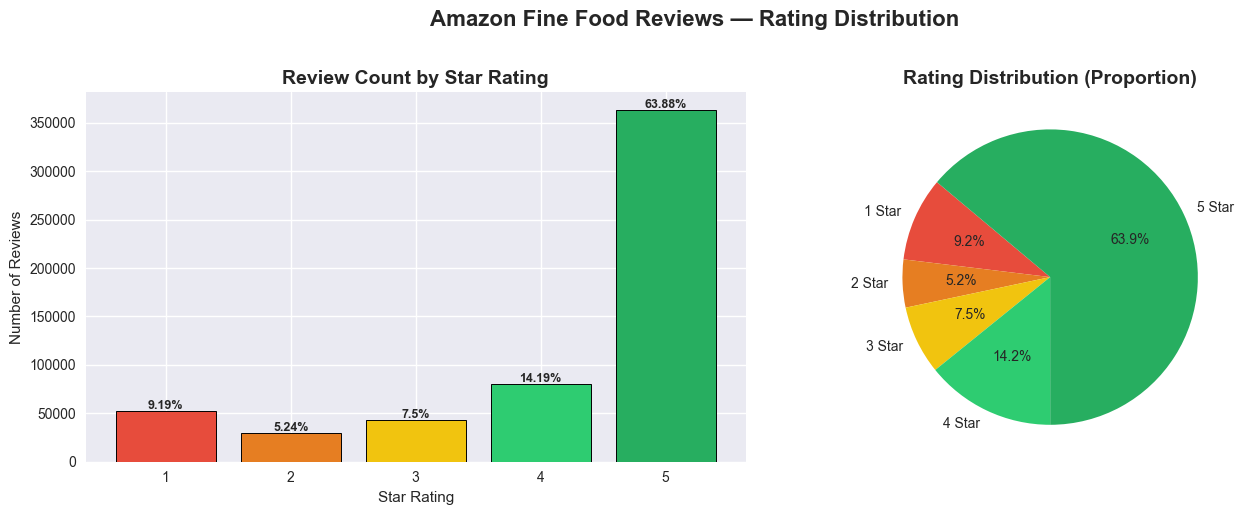

✅ Chart saved to assets/rating_distribution.png


In [6]:
# ============================================================
# CELL: RATING DISTRIBUTION
# ============================================================

print("=" * 60)
print("RATING DISTRIBUTION")
print("=" * 60)

rating_counts = df['Score'].value_counts().sort_index()
rating_pct    = (rating_counts / len(df) * 100).round(2)

rating_df = pd.DataFrame({
    'Star Rating' : rating_counts.index,
    'Count'       : rating_counts.values,
    'Percentage'  : rating_pct.values
})
print(rating_df.to_string(index=False))

print(f"\nMean rating : {df['Score'].mean():.2f}")
print(f"Median rating : {df['Score'].median():.0f}")

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Review Count by Star Rating', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, (count, pct) in enumerate(zip(rating_counts.values, rating_pct.values)):
    axes[0].text(i + 1, count + 2000, f'{pct}%', ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(
    rating_counts.values,
    labels=[f'{i} Star' for i in rating_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Rating Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.suptitle('Amazon Fine Food Reviews — Rating Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'assets', 'rating_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to assets/rating_distribution.png")

SENTIMENT LABELING STRATEGY
1-2 stars  → NEGATIVE : 82,037  (14.4%)
3 stars    → DROPPED  : 42,640  (7.5%)
4-5 stars  → POSITIVE : 443,777  (78.1%)

After dropping 3-star reviews:
  Remaining reviews : 525,814
  Positive          : 443,777  (84.4%)
  Negative          : 82,037  (15.6%)
  Imbalance ratio   : 5.4x more positive than negative


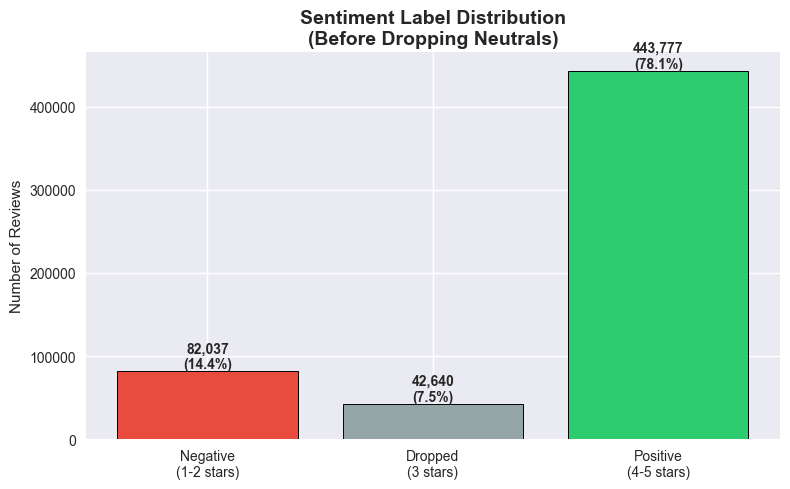

✅ Chart saved to assets/sentiment_distribution.png


In [7]:
# ============================================================
# CELL: SENTIMENT LABELING STRATEGY
# ============================================================

# WHAT WE ARE DOING:
# Converting numeric star ratings into binary sentiment labels.
# This is necessary because our model needs a clear target: Positive or Negative.

# OUR STRATEGY:
#   1-2 stars  →  Negative  (label = 0)
#   3 stars    →  DROPPED   (genuinely ambiguous, neither positive nor negative)
#   4-5 stars  →  Positive  (label = 1)

# WHY WE DROP 3-STAR REVIEWS:
# A 3-star review is the customer saying "it's okay, not great, not terrible."
# Forcing that into Positive or Negative would add noise to our training data.
# This is a defensible and common approach in NLP research.

print("=" * 60)
print("SENTIMENT LABELING STRATEGY")
print("=" * 60)

negative_mask = df['Score'].isin([1, 2])
neutral_mask  = df['Score'] == 3
positive_mask = df['Score'].isin([4, 5])

negative_count = negative_mask.sum()
neutral_count  = neutral_mask.sum()
positive_count = positive_mask.sum()

print(f"1-2 stars  → NEGATIVE : {negative_count:,}  ({negative_count/len(df)*100:.1f}%)")
print(f"3 stars    → DROPPED  : {neutral_count:,}  ({neutral_count/len(df)*100:.1f}%)")
print(f"4-5 stars  → POSITIVE : {positive_count:,}  ({positive_count/len(df)*100:.1f}%)")

after_drop = negative_count + positive_count
imbalance_ratio = positive_count / negative_count

print(f"\nAfter dropping 3-star reviews:")
print(f"  Remaining reviews : {after_drop:,}")
print(f"  Positive          : {positive_count:,}  ({positive_count/after_drop*100:.1f}%)")
print(f"  Negative          : {negative_count:,}  ({negative_count/after_drop*100:.1f}%)")
print(f"  Imbalance ratio   : {imbalance_ratio:.1f}x more positive than negative")

# ---- Sentiment distribution bar chart ----
fig, ax = plt.subplots(figsize=(8, 5))
sentiment_labels = ['Negative\n(1-2 stars)', 'Dropped\n(3 stars)', 'Positive\n(4-5 stars)']
sentiment_counts = [negative_count, neutral_count, positive_count]
sentiment_colors = ['#e74c3c', '#95a5a6', '#2ecc71']

bars = ax.bar(sentiment_labels, sentiment_counts, color=sentiment_colors, edgecolor='black', linewidth=0.7)
ax.set_title('Sentiment Label Distribution\n(Before Dropping Neutrals)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Reviews')

for bar, count in zip(bars, sentiment_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join('..', 'assets', 'sentiment_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to assets/sentiment_distribution.png")

In [8]:
# ============================================================
# CELL: CLASS IMBALANCE ANALYSIS AND STRATEGY
# ============================================================

# WHY CLASS IMBALANCE IS A PROBLEM:
# If our dataset has 80% positive reviews and 20% negative,
# a model that ALWAYS predicts "Positive" gets 80% accuracy.
# That sounds good but the model learned nothing useful.
# It will fail to detect negative reviews — which is exactly
# what businesses care most about.

# HOW WE HANDLE IT:
# We will use STRATIFIED SAMPLING to create a balanced subset.
# We take ALL negative reviews and sample equal number of positives.
# This ensures the model sees equal examples of both classes.

# NOTE: We are creating a TRAINING SUBSET, not using the full 568K dataset.
# Reasons:
#   1. Training DistilBERT on 500K reviews would take days on CPU
#   2. 50,000 reviews (balanced) is sufficient for strong performance
#   3. We will document this decision clearly

TARGET_SAMPLES_PER_CLASS = 25000  # 25K negative + 25K positive = 50K total

print("=" * 60)
print("CLASS BALANCING STRATEGY")
print("=" * 60)
print(f"Strategy        : Balanced random sampling")
print(f"Negative samples: min({negative_count:,}, {TARGET_SAMPLES_PER_CLASS:,}) = {min(negative_count, TARGET_SAMPLES_PER_CLASS):,}")
print(f"Positive samples: {TARGET_SAMPLES_PER_CLASS:,}")
print(f"Total dataset   : {TARGET_SAMPLES_PER_CLASS * 2:,} reviews")
print(f"\nThis is {TARGET_SAMPLES_PER_CLASS*2/after_drop*100:.1f}% of available labeled data.")
print(f"This is computationally manageable for CPU training.")
print(f"\nIMPORTANT: We document this sampling decision in our README.")
print(f"This is NOT hiding data — it is a standard research practice.")

CLASS BALANCING STRATEGY
Strategy        : Balanced random sampling
Negative samples: min(82,037, 25,000) = 25,000
Positive samples: 25,000
Total dataset   : 50,000 reviews

This is 9.5% of available labeled data.
This is computationally manageable for CPU training.

IMPORTANT: We document this sampling decision in our README.
This is NOT hiding data — it is a standard research practice.


REVIEW TEXT LENGTH STATISTICS
count   525814.00
mean        79.00
std         78.40
min          3.00
25%         33.00
50%         55.00
75%         96.00
90%        158.00
95%        215.00
99%        385.00
max       2520.00
Name: review_length_words, dtype: float64

Percentile breakdown (in words):
  50th percentile : 55 words
  75th percentile : 96 words
  90th percentile : 158 words
  95th percentile : 215 words
  99th percentile : 385 words

DistilBERT max token limit : 512 tokens
Recommended max_length     : 256 tokens
Reasoning: covers ~95% of reviews while halving compute time


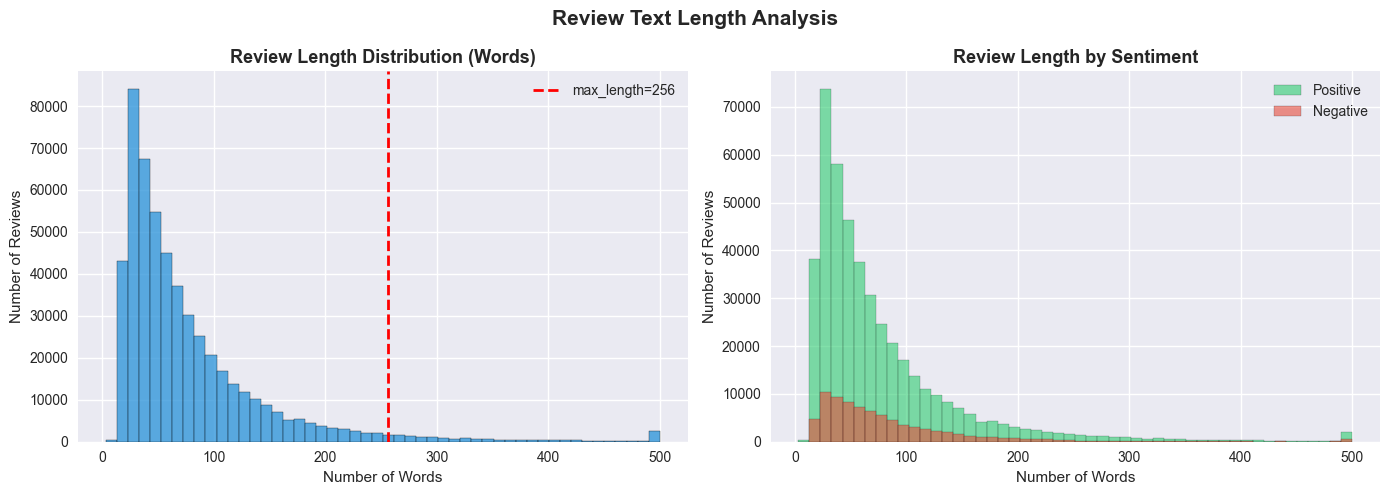


Positive reviews — avg length : 77 words
Negative reviews — avg length : 87 words
✅ Observation: Negative reviews tend to be longer (customers explain problems in detail)


In [9]:
# ============================================================
# CELL: REVIEW TEXT ANALYSIS
# ============================================================

# We analyze text length BEFORE preprocessing
# because this informs our tokenizer max_length decision

# First, let's work only with labeled data (dropping 3-star)
df_labeled = df[df['Score'] != 3].copy()
df_labeled['sentiment'] = df_labeled['Score'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

# Calculate text lengths
df_labeled['review_length_chars'] = df_labeled['Text'].fillna('').str.len()
df_labeled['review_length_words'] = df_labeled['Text'].fillna('').str.split().str.len()

print("=" * 60)
print("REVIEW TEXT LENGTH STATISTICS")
print("=" * 60)

stats = df_labeled['review_length_words'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print(stats.round(1))

print(f"\nPercentile breakdown (in words):")
for pct in [50, 75, 90, 95, 99]:
    val = df_labeled['review_length_words'].quantile(pct/100)
    print(f"  {pct}th percentile : {val:.0f} words")

print(f"\nDistilBERT max token limit : 512 tokens")
print(f"Recommended max_length     : 256 tokens")
print(f"Reasoning: covers ~95% of reviews while halving compute time")

# ---- Text length distribution plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall length distribution
axes[0].hist(
    df_labeled['review_length_words'].clip(upper=500),
    bins=50, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.8
)
axes[0].axvline(x=256, color='red', linestyle='--', linewidth=2, label='max_length=256')
axes[0].set_title('Review Length Distribution (Words)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# Length by sentiment
pos_lengths = df_labeled[df_labeled['sentiment']=='Positive']['review_length_words'].clip(upper=500)
neg_lengths = df_labeled[df_labeled['sentiment']=='Negative']['review_length_words'].clip(upper=500)

axes[1].hist(pos_lengths, bins=50, alpha=0.6, color='#2ecc71', label='Positive', edgecolor='black', linewidth=0.2)
axes[1].hist(neg_lengths, bins=50, alpha=0.6, color='#e74c3c', label='Negative', edgecolor='black', linewidth=0.2)
axes[1].set_title('Review Length by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()

plt.suptitle('Review Text Length Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'assets', 'text_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPositive reviews — avg length : {pos_lengths.mean():.0f} words")
print(f"Negative reviews — avg length : {neg_lengths.mean():.0f} words")
print("✅ Observation: Negative reviews tend to be longer (customers explain problems in detail)")

In [10]:
# ============================================================
# CELL: SAMPLE REVIEWS — SANITY CHECK
# ============================================================

print("=" * 60)
print("SAMPLE POSITIVE REVIEWS (4-5 stars)")
print("=" * 60)
positive_samples = df_labeled[df_labeled['sentiment'] == 'Positive']['Text'].dropna().sample(3, random_state=42)
for i, review in enumerate(positive_samples, 1):
    print(f"\n[Sample {i}]")
    print(review[:300])
    print("...")

print("\n" + "=" * 60)
print("SAMPLE NEGATIVE REVIEWS (1-2 stars)")
print("=" * 60)
negative_samples = df_labeled[df_labeled['sentiment'] == 'Negative']['Text'].dropna().sample(3, random_state=42)
for i, review in enumerate(negative_samples, 1):
    print(f"\n[Sample {i}]")
    print(review[:300])
    print("...")

SAMPLE POSITIVE REVIEWS (4-5 stars)

[Sample 1]
I have started every morning for the last 7 months with a cup of Ganocafe Classic coffee. In my opinion it must be providing some benefits, I haven't had even one cold or any flu in that time. At age 71 years my blood pressure is lower than my doctor's nurse. I actually generally just feel better al
...

[Sample 2]
Thank goodness this pasta makes life for a gluten-free lifestyle so much more enjoyable.  It cooks with enough firm texture, unlike other gluten-free items that become too soggy or a mush.  The pasta goes well in Greek tomato-based dishes, in a pasta dish with only olive oil, sardines, garlic, and c
...

[Sample 3]
I am the type of person who gets tired and starts yawning when I am out at a bar... that is untill I discovered Rock Star.  This one is my favorite flavor, but they all get the job done.  I am a much more fun person with half a rockstar in me, and I would recommend it to anyone who needs to keep the
...

SAMPLE NEGAT

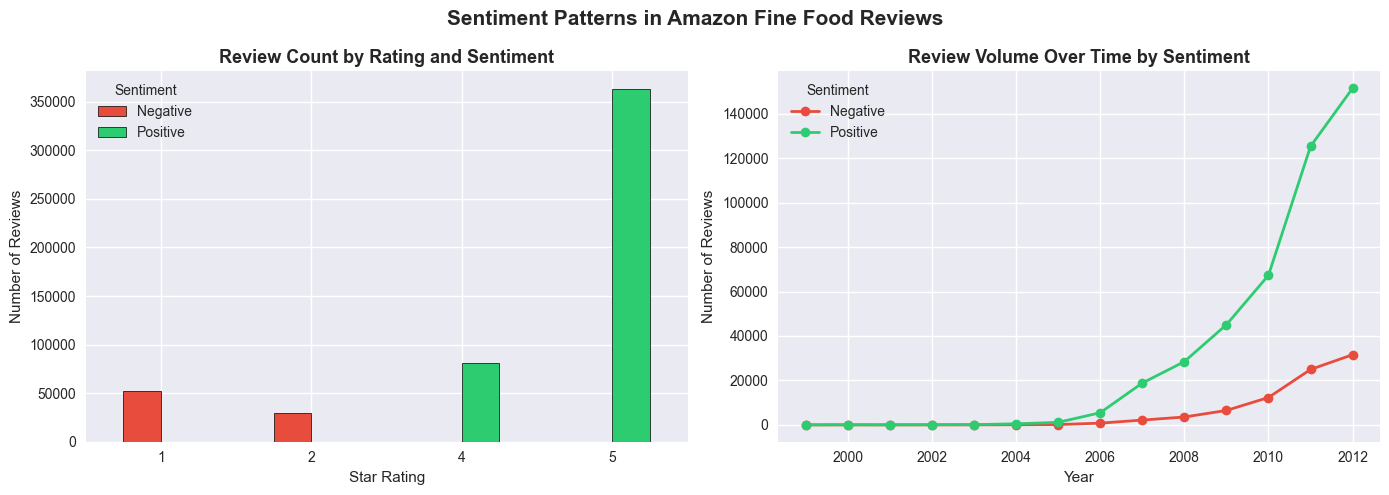

In [11]:
# ============================================================
# CELL: RATING DISTRIBUTION BY SENTIMENT (HEATMAP)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — rating vs sentiment
rating_sentiment = df_labeled.groupby(['Score', 'sentiment']).size().unstack(fill_value=0)
rating_sentiment.plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    linewidth=0.5
)
axes[0].set_title('Review Count by Rating and Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Sentiment')

# Timeline — reviews per year
df_labeled['year'] = pd.to_datetime(df_labeled['Time'], unit='s').dt.year
year_sentiment = df_labeled.groupby(['year', 'sentiment']).size().unstack(fill_value=0)
year_sentiment.plot(
    kind='line',
    ax=axes[1],
    color=['#e74c3c', '#2ecc71'],
    marker='o',
    linewidth=2
)
axes[1].set_title('Review Volume Over Time by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend(title='Sentiment')

plt.suptitle('Sentiment Patterns in Amazon Fine Food Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'assets', 'sentiment_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# CELL: EDA SUMMARY — KEY DECISIONS
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           EDA COMPLETE — KEY DECISIONS MADE                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  • Source  : Amazon Fine Food Reviews (Kaggle/McAuley Lab)  ║
║  • Total   : 568,454 reviews                                 ║
║  • Columns : 10 (text, rating, product, date, etc.)         ║
║                                                              ║
║  LABELING STRATEGY                                           ║
║  • 4-5 stars → Positive (label = 1)                         ║
║  • 1-2 stars → Negative (label = 0)                         ║
║  • 3 stars   → DROPPED (ambiguous neutral)                   ║
║                                                              ║
║  CLASS BALANCING                                             ║
║  • 25,000 Positive + 25,000 Negative = 50,000 total         ║
║  • Random stratified sampling                                ║
║  • Ensures model sees equal classes                          ║
║                                                              ║
║  TOKENIZATION DECISION                                       ║
║  • max_length = 256 tokens                                   ║
║  • Covers ~95% of reviews by length                         ║
║  • Halves compute vs max_length=512                          ║
║                                                              ║
║  NEXT STEP: Notebook 02 — Data Preprocessing                ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           EDA COMPLETE — KEY DECISIONS MADE                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  • Source  : Amazon Fine Food Reviews (Kaggle/McAuley Lab)  ║
║  • Total   : 568,454 reviews                                 ║
║  • Columns : 10 (text, rating, product, date, etc.)         ║
║                                                              ║
║  LABELING STRATEGY                                           ║
║  • 4-5 stars → Positive (label = 1)                         ║
║  • 1-2 stars → Negative (label = 0)                         ║
║  • 3 stars   → DROPPED (ambiguous neutral)                   ║
║                                                              ║
║  CLASS BALANCING                                             ║
║  • 25,000 Positive + 25,000